<h3>import the dataset

In [1]:
from sklearn.datasets import make_circles
import torch


In [2]:
X, y = make_circles(n_samples=1000, noise=0.05, random_state=42)

In [3]:
print(f"X:\n {X[:5]}")
print(f"y:\n {y[:5]}")

X:
 [[ 0.74220688  0.24668576]
 [-0.7340323   0.16869164]
 [-0.82985872  0.22195899]
 [-0.42913559  0.67223019]
 [ 0.44560223 -0.89493556]]
y:
 [1 1 1 1 0]


In [4]:
len(X), len(y)

(1000, 1000)

In [5]:
import pandas as pd
df = pd.DataFrame({"X1": X[:, 0], "X2": X[:, 1], "y": y[:]})

In [6]:
df.head()

,X1,X2,y
0,0.742207,0.246686,1
1,-0.734032,0.168692,1
2,-0.829859,0.221959,1
3,-0.429136,0.672230,1
4,0.445602,-0.894936,0


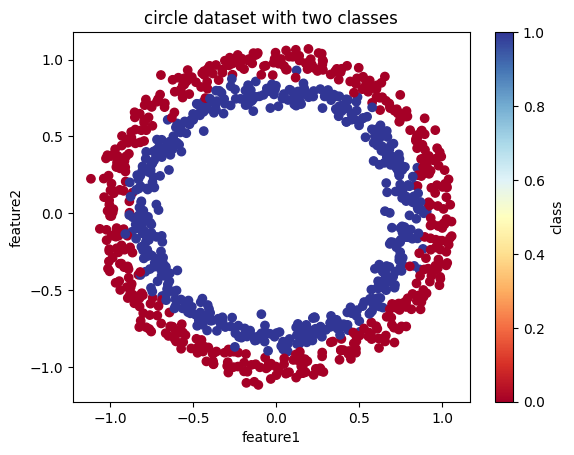

In [7]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c = y, cmap=plt.cm.RdYlBu)
plt.title("circle dataset with two classes")
plt.xlabel("feature1")
plt.ylabel("feature2")
plt.colorbar(label = "class")

In [8]:
X[:5], y[:5]

(array([[ 0.74220688,  0.24668576],
        [-0.7340323 ,  0.16869164],
        [-0.82985872,  0.22195899],
        [-0.42913559,  0.67223019],
        [ 0.44560223, -0.89493556]]),
 array([1, 1, 1, 1, 0]))

<h3>split the dataset into train and test set

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

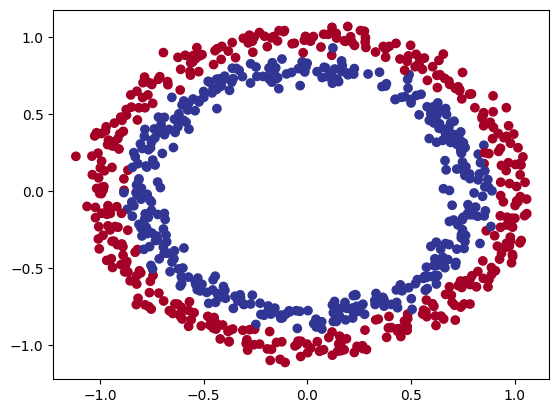

In [10]:
#just visualizing the dataset to know how it is split

plt.scatter(X_train[:, 0], X_train[:, 1], c = y_train, cmap = plt.cm.RdYlBu)
#you will still get a circle because the coordinates dont change

<h3> set up the agnostic code</h3>
when to use gpu?
<br>Only two things need to go to GPU:
<br>1. Your model
<br>2. Your data (inputs and labels) during training/inference

That's it. Everything else stays on CPU.

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

<h3>convert the numpy arrays to tensors and move to gpu

In [12]:
X_train, X_test, y_train, y_test = [torch.tensor(arr).to(device).float() for arr in [X_train, X_test, y_train, y_test]]


In [13]:
X_train.device, X_train.type()

(device(type='cuda', index=0), 'torch.cuda.FloatTensor')

In [14]:
from torch import nn

class circles(nn.Module): #this subclass inherits from the parent class nn.Module
    def __init__(self):
        super().__init__() #we use super inorder to not override the parent class
        self.layer1 = nn.Linear(in_features=2, out_features=2)
        self.layer2 = nn.Linear(in_features=2, out_features=1)
        
    def forward(self, x):
        return self.layer2(self.layer1(x))

In [15]:
model0 = circles().to(device)
model0

circles(
  (layer1): Linear(in_features=2, out_features=2, bias=True)
  (layer2): Linear(in_features=2, out_features=1, bias=True)
)

In [16]:
model0.state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 0.5882,  0.1866],
                      [ 0.4172, -0.2610]], device='cuda:0')),
             ('layer1.bias', tensor([-0.3530,  0.0509], device='cuda:0')),
             ('layer2.weight', tensor([[-0.5349,  0.2332]], device='cuda:0')),
             ('layer2.bias', tensor([0.4745], device='cuda:0'))])

**when the model is this simple you can just use nn.Sequential() instead of creating a subclass of nn.Module**

In [17]:
# model1 = nn.Sequential(
#     nn.Linear(in_features=2, out_features=2),
#     nn.Linear(in_features=2, out_features=1)
# ).to(device)
# model1

In [18]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model0.parameters(), lr = 0.01)

In [19]:
X_test[:5]

tensor([[-0.3625,  0.6737],
        [ 0.0591,  0.9342],
        [-0.6859, -0.3035],
        [-0.2535,  0.9820],
        [ 0.3849, -0.7893]], device='cuda:0')

In [20]:
#testing the prediction of the model on the raw weights i.e. before training the model
model0.eval()
with torch.inference_mode():
    y_pretrained_linear = model0(X_test[:5])
    y_activation = torch.sigmoid(y_pretrained_linear)
torch.round(y_activation)

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]], device='cuda:0')

In [21]:
torch.manual_seed(42)
for epoch in range(1000):
    #training
    model0.train()
    
    #forward pass
    y_pred_train = model0(X_train).squeeze()
    
    #loss
    loss = loss_fn(y_pred_train, y_train)
    
    #turn off the gradient tracking
    optimizer.zero_grad()
    
    loss.backward()
    
    optimizer.step()
    
    model0.eval()
    
    if epoch % 10 == 0:
        print(f"epoch {epoch} loss: {loss}")
        
    

epoch 0 loss: 0.7542288303375244
epoch 10 loss: 0.750249445438385
epoch 20 loss: 0.7465581297874451
epoch 30 loss: 0.7431318759918213
epoch 40 loss: 0.7399494647979736
epoch 50 loss: 0.7369918823242188
epoch 60 loss: 0.7342416048049927
epoch 70 loss: 0.7316826581954956
epoch 80 loss: 0.7293004989624023
epoch 90 loss: 0.7270819544792175
epoch 100 loss: 0.7250146269798279
epoch 110 loss: 0.7230873703956604
epoch 120 loss: 0.7212899327278137
epoch 130 loss: 0.719612717628479
epoch 140 loss: 0.7180472612380981
epoch 150 loss: 0.7165853977203369
epoch 160 loss: 0.7152197360992432
epoch 170 loss: 0.713943600654602
epoch 180 loss: 0.7127506136894226
epoch 190 loss: 0.7116350531578064
epoch 200 loss: 0.7105914950370789
epoch 210 loss: 0.7096149921417236
epoch 220 loss: 0.7087010145187378
epoch 230 loss: 0.707845151424408
epoch 240 loss: 0.7070435881614685
epoch 250 loss: 0.7062926888465881
epoch 260 loss: 0.7055889964103699
epoch 270 loss: 0.7049293518066406
epoch 280 loss: 0.7043108940124512


In [22]:
with torch.inference_mode():
    logits = model0(X_test).squeeze()
    y_pred = (logits > 0).float()
    
    loss = loss_fn(y_pred, y_test)
    
    print(loss)

tensor(0.7418, device='cuda:0')


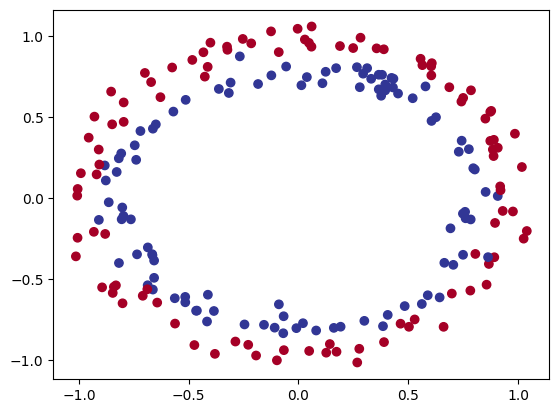

In [23]:
Xt = X_test.cpu().numpy()
yt = y_test.cpu().numpy()
plt.scatter(Xt[:,0], Xt[:,1], c=yt, cmap=plt.cm.RdYlBu)

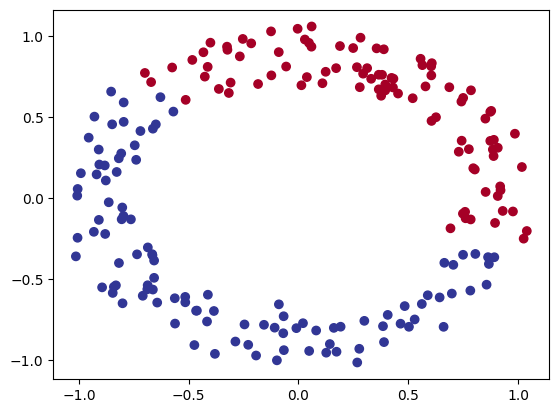

In [24]:
Xt = X_test.cpu().numpy()
yt = y_test.cpu().numpy()
y_pred = y_pred.cpu().numpy()
plt.scatter(Xt[:,0], Xt[:,1], c=y_pred, cmap=plt.cm.RdYlBu)

**which is expected, since you are using linear layers without any non-linear activation functions in between, the decision boundary will be linear, to make the model more powerful you can add non-linear activation functions like ReLU or Sigmoid after each linear layer.**

In [ ]:
model1 = nn.Sequential(
    nn.Linear(in_features=2, out_features=16),
    nn.ReLU(),
    nn.Linear(in_features=16, out_features=16),
    nn.ReLU(),
    nn.Linear(in_features=16, out_features=1),
    # nn.Sigmoid() don't add this because BCEWithLogitsLoss already applies sigmoid activation function to the output of the model
).to(device)
model1

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model1.parameters(), lr = 0.1)

In [26]:
torch.manual_seed(42)
for epoch in range(2000):
    #training
    model1.train()
    #forward pass
    y_pred_train = model1(X_train).squeeze()
    #loss
    loss = loss_fn(y_pred_train, y_train)
    #turn off the gradient tracking
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"epoch {epoch} loss: {loss}")

epoch 0 loss: 0.6975221037864685
epoch 100 loss: 0.6898683309555054
epoch 200 loss: 0.6866466999053955
epoch 300 loss: 0.6826621890068054
epoch 400 loss: 0.677415668964386
epoch 500 loss: 0.6702508926391602
epoch 600 loss: 0.6594114303588867
epoch 700 loss: 0.641437292098999
epoch 800 loss: 0.6122491955757141
epoch 900 loss: 0.564113199710846
epoch 1000 loss: 0.4865047335624695
epoch 1100 loss: 0.3808731138706207
epoch 1200 loss: 0.273655503988266
epoch 1300 loss: 0.19166633486747742
epoch 1400 loss: 0.14268852770328522
epoch 1500 loss: 0.11864741891622543
epoch 1600 loss: 0.09698575735092163
epoch 1700 loss: 0.08356412500143051
epoch 1800 loss: 0.07393106073141098
epoch 1900 loss: 0.06684233248233795


In [29]:
model1.eval()
with torch.inference_mode():
    logits = model1(X_test).squeeze()
    
    loss = loss_fn(logits, y_test)
    y_pred = (logits > 0).float()
    print(f"loss: {loss*100:.2f}%")

loss: 16.29%


In [30]:
X_test_cpu = X_test.cpu().numpy()
y_test_cpu = y_test.cpu().numpy()
test_preds_cpu = y_pred.cpu().numpy()

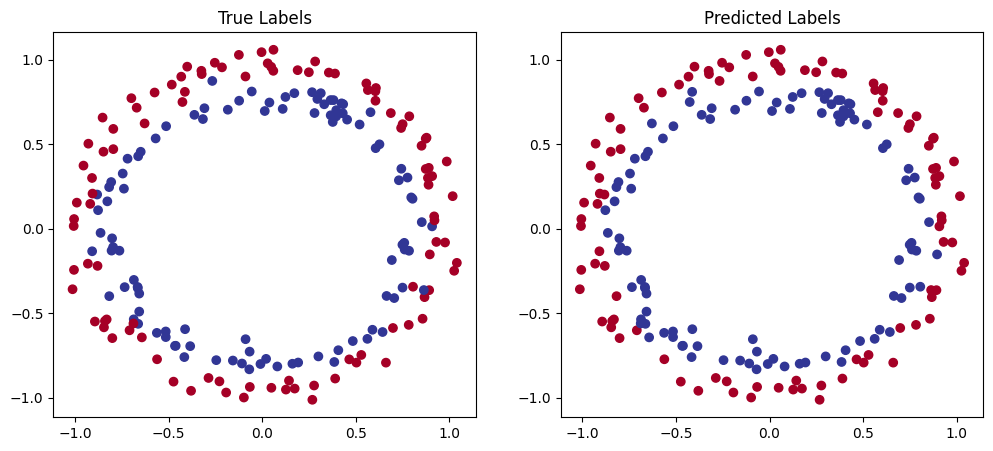

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# True labels
plt.subplot(1,2,1)
plt.scatter(X_test_cpu[:,0], X_test_cpu[:,1],
            c=y_test_cpu, cmap=plt.cm.RdYlBu)
plt.title("True Labels")

# Predicted labels
plt.subplot(1,2,2)
plt.scatter(X_test_cpu[:,0], X_test_cpu[:,1],
            c=test_preds_cpu, cmap=plt.cm.RdYlBu)
plt.title("Predicted Labels")

plt.show()